# UK Flood Risk Exposure Analysis using Python #

### Objective: 
An analysis of UK postcode-level flood risk data to demonstrate catastrophe risk and exposure management concepts, including: flood hazard analysis, exposure aggregation, SQL-based data retrieval, concentration analysis and simulated loss estimation.  

### Tools used: 
- Python
- Jupyter Notebook
- Pandas
- Numpy
- Matplotlib
- SQLite

### Dataset - Open Flood Risk by Postcode Dataset 
The dataset contains postcode level flood risk classifications derived from the Enviornment Agency's 'Risk of Flooding from Rivers and Sea' dataset and Open Postcode Geo. Flood risk is categorised into four bands (High, Medium, Low, and Very Low) and includes postcode-level geographic coordinates. The working dataset used for this project was accessed via Kaggle. 

### Limitations
Real insurance portfolio and exposure data are proprietary and not publicly available. Due to this, insured values were simulated for the purposes of this project to demonstrate exposure aggregation, concentration analysis and catastrophe-style loss estimation techniques.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
fr=pd.read_csv('/Users/sam_bradberry/Documents/Data Science & Python learning/Data to work with/open_flood_risk_by_postcode.csv')
fr.head(10)

,index,TR23 0PR,\N,None,\N.1,\N.2,\N.3,87897,15021,49.953605,-6.352647
0,0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211
5,5,TR24 0QA,\N,NaN,\N,\N,\N,88907,15127,49.955083,-6.338694
6,6,TR24 0QF,\N,NaN,\N,\N,\N,88912,15218,49.955901,-6.338698
7,7,TR24 0QJ,\N,NaN,\N,\N,\N,88982,14871,49.952826,-6.337445
8,8,TR24 0QG,\N,NaN,\N,\N,\N,88991,15341,49.957046,-6.337699
9,9,TR24 0PY,\N,NaN,\N,\N,\N,88993,15029,49.954249,-6.337419


### Data Quality Checks

In [12]:
fr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1443994 entries, 0 to 1443993
Data columns (total 11 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   index      1443994 non-null  int64  
 1   TR23 0PR   1443994 non-null  object 
 2   \N         1443994 non-null  object 
 3   None       122007 non-null   object 
 4   \N.1       1443994 non-null  object 
 5   \N.2       1443994 non-null  object 
 6   \N.3       1443994 non-null  object 
 7   87897      1443994 non-null  int64  
 8   15021      1443994 non-null  int64  
 9   49.953605  1443994 non-null  float64
 10  -6.352647  1443994 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 121.2+ MB


In [13]:
fr.columns

Index(['index', 'TR23 0PR', '\N', 'None', '\N.1', '\N.2', '\N.3', '87897',
       '15021', '49.953605', '-6.352647'],
      dtype='object')

In [14]:
fr.shape

(1443994, 11)

The `info()` output confirms that the dataset contains 1,443,994 postcode-level records across 11 columns. This step was used to check the overall structure of the imported CSV, including column names, data types, memory usage and the number of non-null values in each field.

This is an important first-stage data quality check because it helps identify whether key columns such as `Postcode`, `PROB_4BAND`, `Latitude` and `Longitude` have been imported correctly and whether any missing values need to be handled before further analysis.

The output also shows that several columns contain missing or placeholder values, which need to be considered during the cleaning stage before carrying out flood risk distribution, exposure aggregation and loss modelling.

### Data Cleaning
- Data imported incorrectly with the first row interpreted as headers.
- Reloading dataset with header=None, renaming columns and preparing the dataset for analysis.

In [15]:
fr.columns=['Index','Postcode','FID','PROB_4BAND','SUITABILITY','PUB_DATE','Risk_For_Insurance_SOP','Easting','Northing','Latitude','Longitude']

fr.head(10)

,Index,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
0,0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211
5,5,TR24 0QA,\N,NaN,\N,\N,\N,88907,15127,49.955083,-6.338694
6,6,TR24 0QF,\N,NaN,\N,\N,\N,88912,15218,49.955901,-6.338698
7,7,TR24 0QJ,\N,NaN,\N,\N,\N,88982,14871,49.952826,-6.337445
8,8,TR24 0QG,\N,NaN,\N,\N,\N,88991,15341,49.957046,-6.337699
9,9,TR24 0PY,\N,NaN,\N,\N,\N,88993,15029,49.954249,-6.337419


In [16]:
fr=fr.iloc[:,1:]

In [17]:
fr.shape

(1443994, 10)

In [18]:
fr.head(10)

,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211
5,TR24 0QA,\N,NaN,\N,\N,\N,88907,15127,49.955083,-6.338694
6,TR24 0QF,\N,NaN,\N,\N,\N,88912,15218,49.955901,-6.338698
7,TR24 0QJ,\N,NaN,\N,\N,\N,88982,14871,49.952826,-6.337445
8,TR24 0QG,\N,NaN,\N,\N,\N,88991,15341,49.957046,-6.337699
9,TR24 0PY,\N,NaN,\N,\N,\N,88993,15029,49.954249,-6.337419


In [27]:
fr=fr.replace(r'\N', np.nan)

In [28]:
fr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1443994 entries, 0 to 1443993
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Postcode                1443994 non-null  object 
 1   FID                     122007 non-null   object 
 2   PROB_4BAND              122007 non-null   object 
 3   SUITABILITY             122007 non-null   object 
 4   PUB_DATE                122007 non-null   object 
 5   Risk_For_Insurance_SOP  122007 non-null   object 
 6   Easting                 1443994 non-null  int64  
 7   Northing                1443994 non-null  int64  
 8   Latitude                1443994 non-null  float64
 9   Longitude               1443994 non-null  float64
dtypes: float64(2), int64(2), object(6)
memory usage: 110.2+ MB


In [29]:
fr_clean=fr.dropna()

In [30]:
fr_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122007 entries, 250 to 1443993
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Postcode                122007 non-null  object 
 1   FID                     122007 non-null  object 
 2   PROB_4BAND              122007 non-null  object 
 3   SUITABILITY             122007 non-null  object 
 4   PUB_DATE                122007 non-null  object 
 5   Risk_For_Insurance_SOP  122007 non-null  object 
 6   Easting                 122007 non-null  int64  
 7   Northing                122007 non-null  int64  
 8   Latitude                122007 non-null  float64
 9   Longitude               122007 non-null  float64
dtypes: float64(2), int64(2), object(6)
memory usage: 10.2+ MB


In [31]:
fr_clean.head(10)

,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
250,TR19 7PL,2752,High,County to Town,2009-08-01,Yes,137342,31843,50.128392,-5.676455
260,TR19 7PG,2752,High,County to Town,2009-08-01,Yes,137528,31842,50.128465,-5.673858
271,TR19 7PH,2752,High,County to Town,2009-08-01,Yes,137639,31886,50.128909,-5.672338
370,TR19 7TW,301675,Low,County to Town,2009-08-01,No,138998,34624,50.154083,-5.655239
374,TR19 7TN,301509,Low,County to Town,2009-08-01,No,139059,34530,50.153266,-5.654322
509,TR19 6BW,298443,Low,County to Town,2009-08-01,No,143775,25269,50.072196,-5.582225
558,TR19 6XQ,298173,Low,County to Town,2009-08-01,No,144797,24349,50.064378,-5.567358
607,TR20 8FR,2055,High,County to Town,2009-08-01,Yes,145464,29370,50.109733,-5.561400
613,TR20 8TL,2055,High,County to Town,2009-08-01,Yes,145538,29328,50.109388,-5.560339
635,TR20 8XN,301371,Low,County to Town,2009-08-01,No,145768,34063,50.151989,-5.560285


### SQLite Database Integration

To demonstrate insurance analytics workflow, a cleaned flood risk dataset was imported into a SQLite database.

Rather than analysing the CSV directly throughout the project, SQL queries were used to retrieve summarised information before continuing the analysis in Python.

In [11]:
import sqlite3

In [12]:
connection=sqlite3.connect('/Users/sam_bradberry/Documents/Data Science & Python learning/UK Flood Risk Project:/Database:/flood_risk.db')

In [52]:
query= """
SELECT
PROB_4BAND,
COUNT(*) AS Exposure
FROM FloodRisk
WHERE PROB_4BAND IS NOT NULL
GROUP BY PROB_4BAND;
"""

risk_summary=pd.read_sql_query(query,connection)

risk_order=["Very Low","Low","Medium","High"]

risk_summary["PROB_4BAND"]=pd.Categorical(
    risk_summary["PROB_4BAND"],
    categories=risk_order,
    ordered=True)

risk_summary=risk_summary.sort_values("PROB_4BAND")

risk_summary

,PROB_4BAND,Exposure
3,Very Low,4773
1,Low,80001
2,Medium,24928
0,High,12305


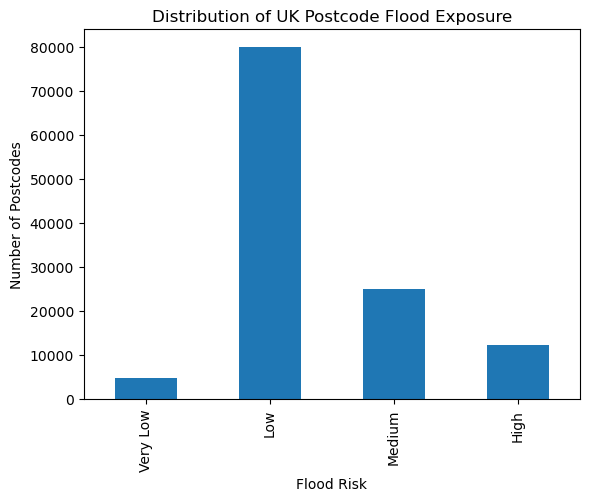

In [53]:
ax=risk_summary.plot(x="PROB_4BAND",y="Exposure",kind="bar",legend=False)

ax.set_xlabel("Flood Risk")
ax.set_ylabel("Number of Postcodes")
ax.set_title("Distribution of UK Postcode Flood Exposure")

plt.show()

The distribution demonstrates a clear concentration of postcode records within the low flood risk band, with exposure reducing steadily as flood probability increases. This indicates that high flood hazard exposure is not uniformly distributed but instead confined to a relatively small subset of locations. However, this potentially highlights the importance of identifying and managing accumulations of high-risk exposure, where a single flood event has the potential to generate disproportionate losses.

### SQL Analysis 2 – Spatial Distribution of High Flood Risk Locations

Whilst the previous SQL analysis quantified the distribution of flood risk categories, this analysis isolates only the highest flood risk locations before visualising their spatial distribution.

In [56]:
high_risk_query="""
SELECT
Latitude,
Longitude
FROM FloodRisk
WHERE PROB_4BAND='High';
"""

high_risk_locations=pd.read_sql_query(high_risk_query,connection)

high_risk_locations.head()

,Latitude,Longitude
0,50.128392,-5.676455
1,50.128465,-5.673858
2,50.128909,-5.672338
3,50.109733,-5.561400
4,50.109388,-5.560339


In [57]:
len(high_risk_locations)

12305

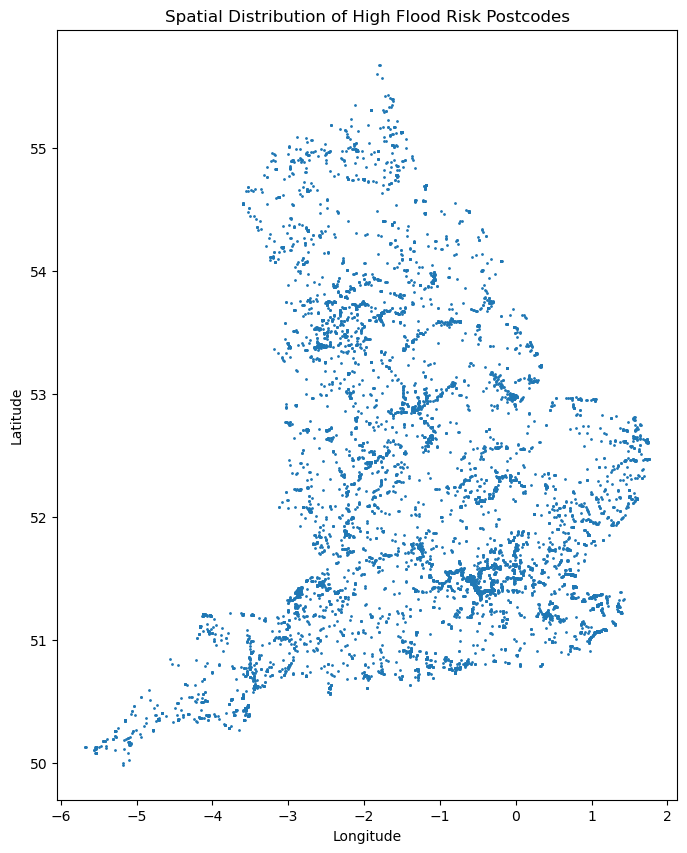

In [62]:
plt.figure(figsize=(8,10))

plt.scatter(
    high_risk_locations["Longitude"],
        high_risk_locations["Latitude"],
    s=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of High Flood Risk Postcodes")

plt.show()
        

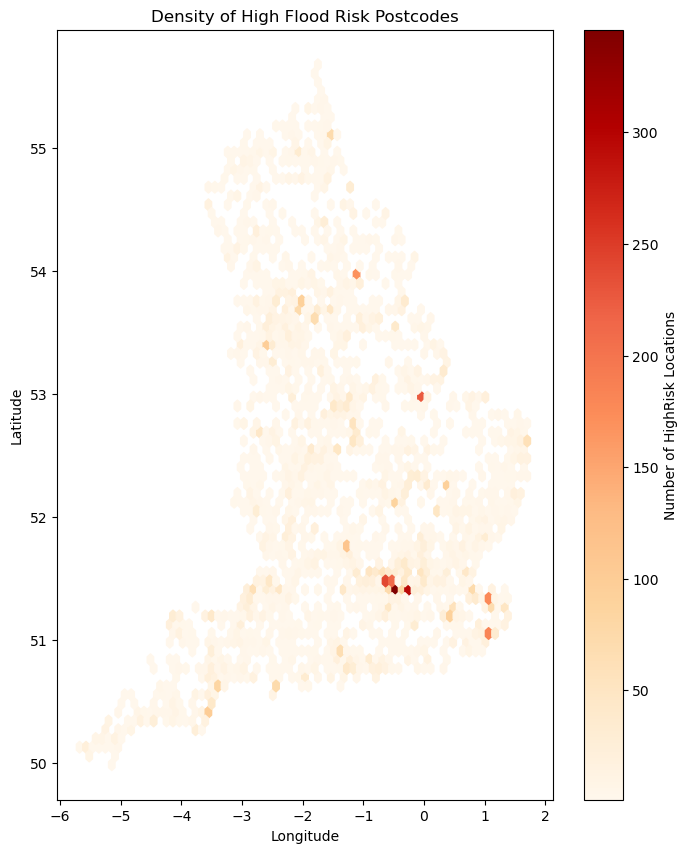

In [70]:
plt.figure(figsize=(8,10))

plt.hexbin(
    high_risk_locations["Longitude"],
    high_risk_locations["Latitude"],
    gridsize=70,
    cmap="OrRd",
    mincnt=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Density of High Flood Risk Postcodes")
plt.colorbar(label="Number of HighRisk Locations")

plt.show()

SQL was used to collect postcode records classified within the high flood risk category before importing the results into Python for geospatial visualisation. The density map highlights spatial clusterings of high-risk locations rather than an even national distribution. This reinforces the interpretation from SQL Analysis 1- geographically concentrated risks can significantly increase the potential portfolio impact of a single flood event.

### Flood Hazard Distribution

In [32]:
fr_clean.describe(include='all')

,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
count,122007,122007,122007,122007,122007,122007,122007.000000,122007.000000,122007.000000,122007.000000
unique,122007,28958,4,5,19,2,NaN,NaN,NaN,NaN
top,TR19 7PL,1407444,Low,County to Town,2013-12-22,No,NaN,NaN,NaN,NaN
freq,1,8149,80001,70851,71618,101603,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,474787.649340,267688.170212,52.295624,-0.908620
std,NaN,NaN,NaN,NaN,NaN,NaN,85465.705683,123099.267473,1.110102,1.240291
min,NaN,NaN,NaN,NaN,NaN,NaN,137342.000000,14548.000000,49.987482,-5.676455
25%,NaN,NaN,NaN,NaN,NaN,NaN,419945.000000,175941.000000,51.468567,-1.700957
50%,NaN,NaN,NaN,NaN,NaN,NaN,504560.000000,218206.000000,51.856652,-0.475586
75%,NaN,NaN,NaN,NaN,NaN,NaN,533378.000000,388370.000000,53.389637,-0.067859


In [33]:
fr_clean['PROB_4BAND'].value_counts()

PROB_4BAND
Low         80001
Medium      24928
High        12305
Very Low     4773
Name: count, dtype: int64

### Exposure Aggregation and Modelling
As insurance portfolio data is not publicly available, simulated insured property values are randomly assigned (£75,000 - £1,000,000) to demonstrate exposure management concepts.

Text(0, 0.5, 'Number of Postcodes')

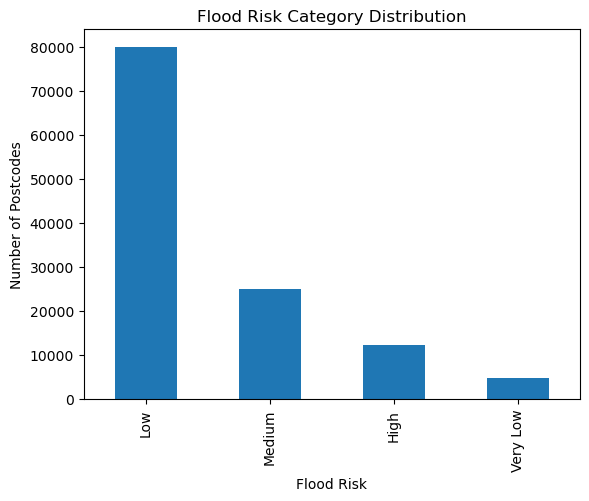

In [34]:
fr_clean['PROB_4BAND'].value_counts().plot(kind='bar')

plt.title('Flood Risk Category Distribution')
plt.xlabel('Flood Risk')
plt.ylabel('Number of Postcodes')

Text(0, 0.5, 'Number of Postcodes')

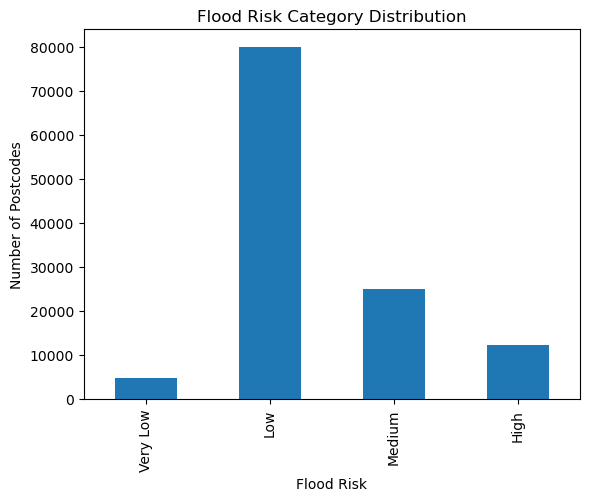

In [35]:
risk_order=['Very Low','Low','Medium','High']
risk_counts=fr_clean['PROB_4BAND'].value_counts().reindex(risk_order)

risk_counts.plot(kind='bar')

plt.title('Flood Risk Category Distribution')
plt.xlabel('Flood Risk')
plt.ylabel('Number of Postcodes')

In [37]:
fr_clean['Insured_Value']=np.random.randint(75000,1000000,size=len(fr_clean))

/var/folders/7h/lmcdbz8j4jdftjh2gw567jpr0000gn/T/ipykernel_2053/3402481351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fr_clean['Insured_Value']=np.random.randint(75000,1000000,size=len(fr_clean))


In [38]:
risk_exposure=fr_clean.groupby('PROB_4BAND')['Insured_Value'].sum()

print(risk_exposure)

PROB_4BAND
High         6611359450
Low         43053589792
Medium      13356748849
Very Low     2608413421
Name: Insured_Value, dtype: int64


Text(0.5, 0, 'Flood Risk')

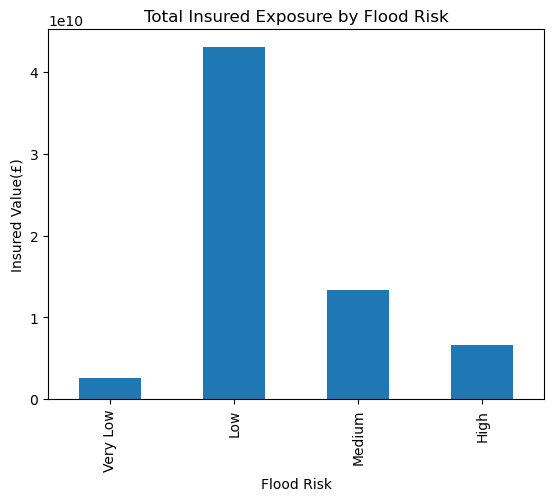

In [39]:
risk_order=['Very Low','Low','Medium','High']
risk_exposure=fr_clean.groupby('PROB_4BAND')['Insured_Value'].sum().reindex(risk_order)

risk_exposure.plot(kind='bar')

plt.title('Total Insured Exposure by Flood Risk')
plt.ylabel('Insured Value(£)')
plt.xlabel('Flood Risk')

### Flood Loss Model

This loss model is applied using assumed damage ratios for each flood risk category. The values are:

| Flood Risk Category | Assumed Damage Ratio |
|---------------------|---------------------|
| High                | 10%                 |
| Medium              | 5%                  |
| Low                 | 2%                  |
| Very Low            | 0.5%                |

These assumptions are for the purposes of this workbook only and are not intended to represent real catastrophe model values.

In [41]:
loss_values={
    'High':0.10,
    'Medium':0.05,
    'Low':0.02,
    'Very Low':0.005}

In [43]:
fr_clean['Loss']=fr_clean['PROB_4BAND'].map(loss_values)

/var/folders/7h/lmcdbz8j4jdftjh2gw567jpr0000gn/T/ipykernel_2053/905710355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fr_clean['Loss']=fr_clean['PROB_4BAND'].map(loss_values)


In [44]:
fr_clean['Estimated_Loss']=fr_clean['Insured_Value']*fr_clean['Loss']

/var/folders/7h/lmcdbz8j4jdftjh2gw567jpr0000gn/T/ipykernel_2053/1135890306.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fr_clean['Estimated_Loss']=fr_clean['Insured_Value']*fr_clean['Loss']


In [45]:
estimated_loss=fr_clean.groupby('PROB_4BAND')['Estimated_Loss'].sum()

print(estimated_loss)

PROB_4BAND
High        6.611359e+08
Low         8.610718e+08
Medium      6.678374e+08
Very Low    1.304207e+07
Name: Estimated_Loss, dtype: float64


Text(0, 0.5, 'Estimated Loss(£)')

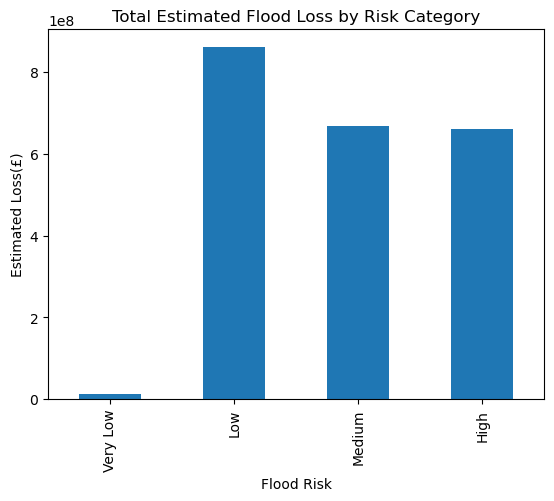

In [46]:
risk_order=['Very Low','Low','Medium','High']
estimated_loss=estimated_loss.reindex(risk_order)

estimated_loss.plot(kind='bar')

plt.title('Total Estimated Flood Loss by Risk Category')
plt.xlabel('Flood Risk')
plt.ylabel('Estimated Loss(£)')

Text(0, 0.5, '')

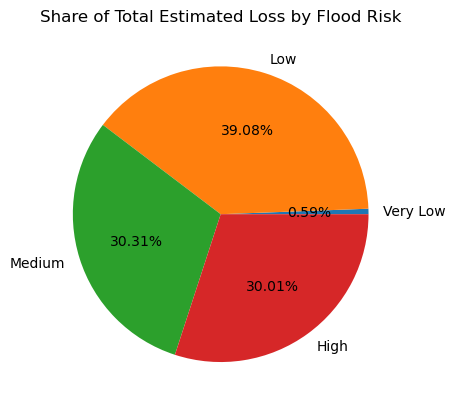

In [47]:
estimated_loss.plot(kind='pie',autopct='%1.2f%%')

plt.title('Share of Total Estimated Loss by Flood Risk')
plt.ylabel('')

Text(0, 0.5, '')

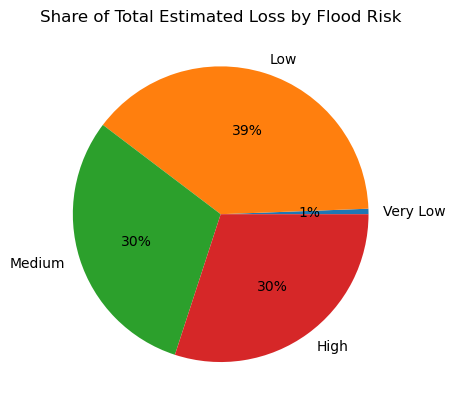

In [48]:
estimated_loss.plot(kind='pie',autopct='%1.0f%%')

plt.title('Share of Total Estimated Loss by Flood Risk')
plt.ylabel('')

### Exposure Concentrations
The following analysis identifies the postcode areas with the highest and lowest levels of insured exposure.

In [49]:
fr_clean['Postcode_Area']=fr_clean['Postcode'].str.split().str[0]

/var/folders/7h/lmcdbz8j4jdftjh2gw567jpr0000gn/T/ipykernel_2053/3727444504.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fr_clean['Postcode_Area']=fr_clean['Postcode'].str.split().str[0]


In [50]:
area_exposure=fr_clean.groupby('Postcode_Area')['Insured_Value'].sum()

Text(0.5, 0, 'Insured Value (£)')

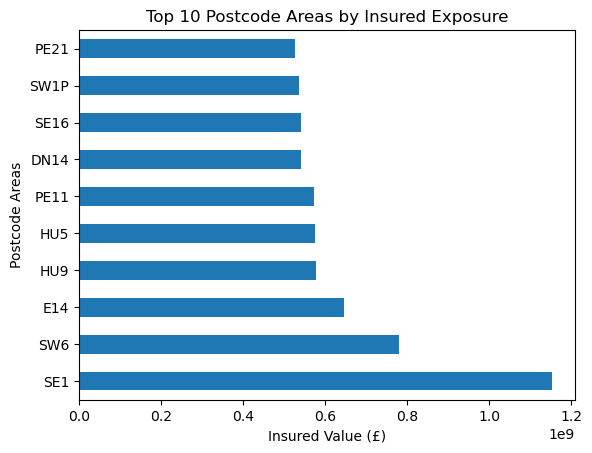

In [51]:
top10=area_exposure.sort_values(ascending=False).head(10)

top10.plot(kind='barh')

plt.title('Top 10 Postcode Areas by Insured Exposure')
plt.ylabel('Postcode Areas')
plt.xlabel('Insured Value (£)')

The above postcode areas represent the largest concentrations of insured exposure to flood risk. These postcodes may warrant further review for managing potential loss.

Text(0.5, 0, 'Insured Value (£)')

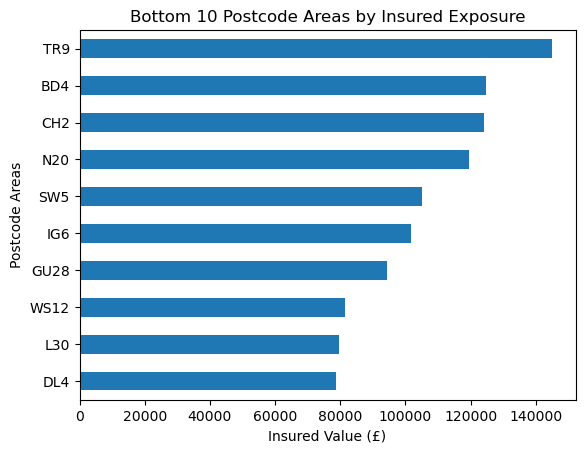

In [52]:
top10=area_exposure.sort_values(ascending=True).head(10)

top10.plot(kind='barh')

plt.title('Bottom 10 Postcode Areas by Insured Exposure')
plt.ylabel('Postcode Areas')
plt.xlabel('Insured Value (£)')

The above postcode areas contribute the least to the overall portfolio exposure. These postcodes therefore have a limited impact on loss potential.

### Full Distribution of Insurance Exposure using bins

Text(0, 0.5, 'Frequency')

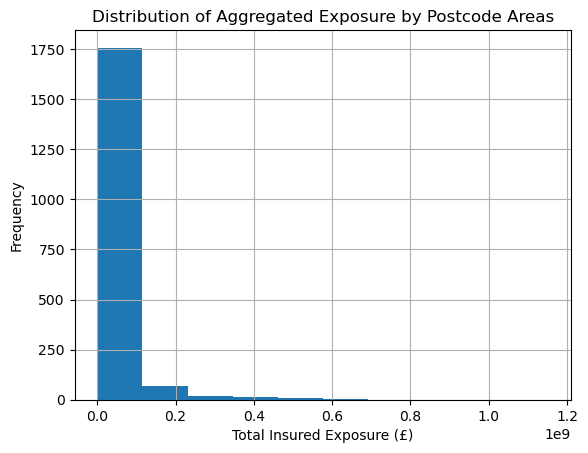

In [55]:
area_exposure.hist(bins=10)

plt.title('Distribution of Aggregated Exposure by Postcode Areas')
plt.xlabel('Total Insured Exposure (£)')
plt.ylabel('Frequency')

By narrowing the histogram bins to 10, the distribution of aggregated insured exposure becomes more clearly observable. The results indicate that the majority of postcode areas within the simulated portfolio contain relatively lower levels of aggregated insured exposure, while the frequency of postcode areas declines significantly as total exposure increases. This interpretation suggests a positively skewed exposure distribution, whereby a relatively small number of postcode areas contain disproportionately large concentrations of insured value. These higher concentration areas may represent greater risk during severe flood events, as shown when we combine this with the data of estimated losses- High Risk postcode areas, whilst distributed in a clear minority, present a disproportionately high contribution to potential loss.

### Simplified Catastrophe Loss Simulation

The previous sections estimated flood exposure and simulated insured values across UK postcodes. This section extends the analysis by demonstrating a simplified catastrophe loss simulation framework.

Rather than applying a single deterministic loss assumption, illustrative damage ratios are randomly generated based on each postcode’s flood risk classification. This demonstrates how uncertainty in damage severity can be introduced into a loss modelling workflow.

The same methodology can be repeated across the simulated portfolio to produce an illustrative loss distribution, from which simplified AAL and PML-style metrics can be estimated.

This is intended solely to demonstrate catastrophe modelling concepts using publicly available hazard data and simulated exposure values. They should not be interpreted as representative of a commercial catastrophe model or real insurance portfolio losses.

The following were simulated to produce an illustrative catastrophe loss simulation.

| Flood Risk | Mean Damage Ratio | Standard Deviation |
|------------|------------------:|-------------------:|
| Very Low | 0.3% | 0.1% |
| Low | 1.0% | 0.3% |
| Medium | 5.0% | 1.0% |
| High | 20.0% | 5.0% |

In [56]:
sim_df=fr_clean[["PROB_4BAND","Insured_Value"]].copy()

sim_df=sim_df.dropna()

sim_df.head()

,PROB_4BAND,Insured_Value
250,High,194540
260,High,332591
271,High,938816
370,Low,713156
374,Low,470480


In [57]:
damage_ratios={
    "Very Low":(0.003,0.001),
    "Low":(0.01, 0.003),
    "Medium":(0.05, 0.01),
    "High":(0.20,0.05)}

damage_ratios

{'Very Low': (0.003, 0.001),
 'Low': (0.01, 0.003),
 'Medium': (0.05, 0.01),
 'High': (0.2, 0.05)}

In [58]:
eg=sim_df.iloc[0]

eg

PROB_4BAND         High
Insured_Value    194540
Name: 250, dtype: object

In [59]:
risk=eg["PROB_4BAND"]

risk

'High'

In [60]:
damage_ratios[risk]

(0.2, 0.05)

Mean Damage Ratio = 20%. Standard Deviation is 5%.

In [61]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.18280243587270867

In [62]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.28608300970398826

In [63]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.059267966593346634

In [64]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.1579195043382383

In [65]:
mean,std=damage_ratios[risk]

damage=np.random.normal(mean,std)

damage

0.16339066571637711

The random damage ratio generated above represents a single simulated flood event affecting one insured property.

The damage ratio changes each time the cell is executed because it is centred on the simulated damage ratio for that flood risk category. This reflects the uncertainty in 'real world' scenarios like flood events, where the severity of damage varies according to factors such as flood depth, duration, infrastructure quality/age and local conditions.

Generating different damage ratios for repeated simulations allows many flood scenarios to be explored rather than relying on a single fixed estimate.

In [68]:
insured=eg["Insured_Value"]

loss=insured*damage

loss

np.float64(31786.020108464003)

The simulated damage ratio has now been applied to the insured value of a single property to estimate an illustrative flood loss.

This (£31786.02) represents the estimated financial impact of one hypothetical flood event affecting one insured location. Whilst only a single property has been modelled at this stage, the same methodology can subsequently be applied across the entire simulated portfolio and repeated thousands of times to generate a portfolio loss distribution from which Average Annual Loss (AAL) and Probable Maximum Loss (PML) metrics can be estimated.

### Conclusions

This project demonstrates a simplified catastrophe risk and exposure management workflow using publicly available UK postcode flood risk data. Python was used alongside SQL to clean, query and analyse the dataset before visualising flood hazard, exposure concentrations and simulated portfolio losses.

The analysis showed that the majority of UK postcodes fall within the **Very Low** and **Low** flood risk categories, with relatively few classified as **Medium** or **High** risk. This suggests that flood hazard is concentrated within a smaller number of locations rather than being evenly distributed across the country. From an insurance perspective, identifying these higher-risk concentrations is important, as they have the potential to generate disproportionately large losses during major flood events.

To build on this, a simplified single-property loss simulation was developed using simulated insured values and illustrative damage ratios. This demonstrates the conceptual basis of Monte Carlo-style catastrophe loss modelling, where the same logic could be extended across the full portfolio and repeated many times to estimate a portfolio loss distribution, AAL and PML.

### Limitations

- Insured values were simulated, as real insurance exposure data is not publicly available.
- Damage ratios were illustrative assumptions and were not based on historical claims data or vulnerability models.
- The simulation does not include individual flood events.
- The results should therefore be viewed as a demonstration of methodology rather than representative insurance losses.

### Future Improvements

There are several ways this project could be expanded in the future:

- Use realistic flood event sets rather than illustrative damage ratios.
- Produce interactive geospatial flood exposure maps.
- Incorporate property-level vulnerability values.
